## Analysis of the Quasiparticle couplings for the Gadget Hamiltonian

In [15]:
import numpy as np
import json
import matplotlib.pyplot as plt

In [2]:
data_onebody=np.load('data/matrix_elements_h_eff_2body/one_body_nn_p.npz')
keys=data_onebody['keys']
values=data_onebody['values']
n_qubits=3

g_onebody={}
g_matrix=np.zeros((n_qubits,n_qubits))
for a,key in enumerate(keys):
    i,j=key
    g_onebody[(i,j)]=values[a]
    if i!=j:
        g_matrix[i,j]=values[a]

# print(t_onebody)
# t_onebody.pop((0,1))
# t_onebody.pop((0,2))
# t_onebody.pop((1,2))

print(g_onebody)

{(np.int64(0), np.int64(0)): np.float64(-8.4321), (np.int64(0), np.int64(1)): np.float64(1.0430999999999995), (np.int64(0), np.int64(2)): np.float64(-3.763858685577873), (np.int64(1), np.int64(0)): np.float64(1.0430999999999995), (np.int64(1), np.int64(1)): np.float64(-8.4321), (np.int64(1), np.int64(2)): np.float64(3.763858685577873), (np.int64(2), np.int64(0)): np.float64(-3.763858685577873), (np.int64(2), np.int64(1)): np.float64(3.763858685577873), (np.int64(2), np.int64(2)): np.float64(-5.1203)}


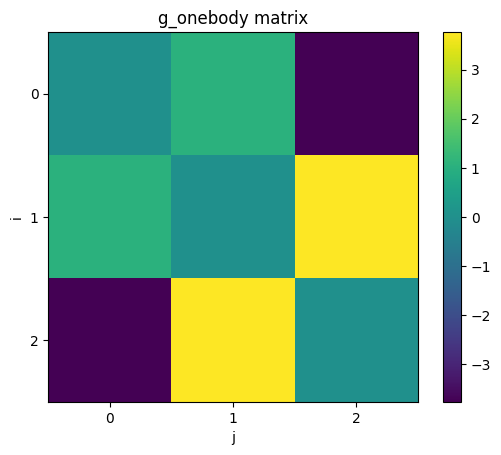

In [16]:
plt.imshow(g_matrix, cmap='viridis')
plt.colorbar()
plt.title('g_onebody matrix')
plt.xlabel('j')
plt.ylabel('i')
plt.xticks(range(n_qubits))
plt.yticks(range(n_qubits))
plt.show()

#### Check if I can get a set of $d_i$ that can provide the $g_{ij}$

In [ ]:
import numpy as np
from scipy.optimize import minimize

n = 3

def reconstructed(d):
    outer = -np.outer(d, d)
    np.fill_diagonal(outer, 0)
    return outer

def make_objective(g):
    mask = np.triu(np.ones((n, n)), k=1)
    def objective(d):
        diff = reconstructed(d) - g
        return np.sum((diff * mask) ** 2)
    def gradient(d):
        diff = reconstructed(d) - g
        diff_sym = (mask + mask.T) * diff
        return -2 * diff_sym @ d
    return objective, gradient

def optimize(g, n_restarts=2000):
    obj, grad = make_objective(g)
    
    # Check flux
    flux = g[0,1] * g[0,2] * g[1,2]
    print(f"Flux g12*g13*g23 = {flux:.4f} "
          f"({'pi-flux' if flux < 0 else 'zero-flux'})")
    print(f"Eigenvalues of G: {np.linalg.eigvalsh(g).round(4)}")
    print(f"Rank of G: {np.linalg.matrix_rank(g, tol=1e-10)}")
    
    # Warm start from leading eigenvector of -G
    eigvals, eigvecs = np.linalg.eigh(-g)
    idx = np.argmax(np.abs(eigvals))
    d0 = np.sqrt(max(abs(eigvals[idx]), 1e-8)) * eigvecs[:, idx]
    
    best = minimize(obj, d0, jac=grad, method='L-BFGS-B',
                    options={'ftol':1e-15, 'gtol':1e-10, 'maxiter':10000})
    
    for _ in range(n_restarts):
        d_init = np.random.randn(n) * 2
        res = minimize(obj, d_init, jac=grad, method='L-BFGS-B',
                       options={'ftol':1e-15, 'gtol':1e-10, 'maxiter':10000})
        if res.fun < best.fun:
            best = res
    
    d_opt = best.x
    print(f"\nOptimal d: {d_opt.round(6)}")
    print(f"Residual loss: {best.fun:.2e}")
    print(f"Reconstructed -d_i*d_j:")
    print(reconstructed(d_opt).round(4))
    print("Per-pair errors:")
    for i in range(n):
        for j in range(i+1, n):
            approx = -d_opt[i]*d_opt[j]
            target = g[i,j]
            print(f"  g_{i+1}{j+1}: target={target:+.4f}, "
                  f"approx={approx:+.4f}, error={abs(approx-target):.6f}")
    return d_opt

# === Case 1: pi-flux ===
print("="*50)
print("Case 1: pi-flux  g12>0, g13<0, g23>0")
print("="*50)

d1 = optimize(g_matrix)

# === Case 2: your specific case g12>0, g23=+t, g31=-t ===
print("\n" + "="*50)
print("Case 2: g12=1, g23=0.5, g31=-0.5")
print("="*50)

d2 = optimize(g_matrix)

# === Case 3: zero-flux (should be perfect) ===
print("\n" + "="*50)
print("Case 3: zero-flux g12=1, g13=1, g23=-1")
print("="*50)
g3 = np.array([[ 0,  1,  1],
               [ 1,  0, -1],
               [ 1, -1,  0]], dtype=float)
d3 = optimize(g3)